In [1]:
# 1. Setting Up the Environment and Importing Libraries
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import time
import random
from collections import deque

if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

In [2]:
# 2. Preparing the Environment

class QuantumHypercubeEnv(gym.Env):
    def __init__(self, n_qubits=6):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_states = 2 ** n_qubits
        self.observation_space = spaces.Discrete(self.n_states)
        self.action_space = spaces.Discrete(self.n_qubits)
        self.target_state = self.n_states - 1
        self.max_steps = 40
        self.current_state = 0
        self.current_step = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_state = 0
        self.current_step = 0
        return self.current_state, {}

    def step(self, action):
        self.current_step += 1
        # if np.random.rand() < 0.15:
        #     action = np.random.randint(self.action_space.n)
        
        flip_mask = 1 << action
        self.current_state = self.current_state ^ flip_mask

        terminated = False
        truncated = False
        reward = -0.1

        if self.current_state == self.target_state:
            reward = 10.0
            terminated = True
        elif self.current_step >= self.max_steps:
            truncated = True

        return self.current_state, reward, terminated, truncated, {}

env = QuantumHypercubeEnv(n_qubits=6)
n_states = env.observation_space.n
n_actions = env.action_space.n

def get_state(obs):
    return obs[0] if isinstance(obs, tuple) else obs

def get_state_vec(state):
    return torch.tensor([int(b) for b in format(state, '06b')], dtype=torch.float32)

In [ ]:
# 3. Definition of the Classic Model

class ReplayBuffer:
    def __init__(self, capacity=5000):
        self.buffer = deque(maxlen=capacity)
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return zip(*batch)
    def __len__(self):
        return len(self.buffer)

class ClassicalQNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 32),
            nn.ReLU(),
            nn.Linear(32, 6)
        )
    def forward(self, x):
        return self.net(x)

In [ ]:
# 4. Definition of a Quantum Model

# import random
# from collections import deque

dev = qml.device("default.qubit", wires=6)

@qml.qnode(dev, interface="torch")
def qql_circuit(inputs, weights):
    for layer_weights in weights:
        qml.AngleEmbedding(inputs * np.pi, wires=range(6))
        qml.BasicEntanglerLayers(weights=layer_weights.reshape(1, 6), wires=range(6))
    return [qml.expval(qml.PauliZ(i)) for i in range(6)]

class QQLNet(nn.Module):
    def __init__(self, n_layers=4):
        super().__init__()
        self.weights = nn.Parameter(0.01 * torch.randn(n_layers, 6)) 
        self.output_layer = nn.Linear(6, 6) 
        
    def forward(self, x):
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x, dtype=torch.float32)
        res = qql_circuit(x, self.weights)
        res_tensor = torch.stack(res)
        if res_tensor.dim() == 2: 
            res_tensor = res_tensor.T 
        return self.output_layer(res_tensor.float())

In [ ]:
# 5. Standardised training function

def train_model(model_type="classical", episodes=800, batch_size=16):
    model = ClassicalQNet() if model_type == "classical" else QQLNet(n_layers=4)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    buffer = ReplayBuffer()
    
    gamma, epsilon = 0.95, 0.5
    epsilon_min, epsilon_decay = 0.05, 0.99
    history = {'rewards': [], 'success': [], 'param_count': sum(p.numel() for p in model.parameters() if p.requires_grad)}

    for ep in range(episodes):
        state_idx, _ = env.reset()
        ep_reward, is_success = 0, 0
        
        for _ in range(40):
            state_vec = get_state_vec(state_idx)
            with torch.no_grad():
                q_values = model(state_vec)
            
            action = np.random.randint(n_actions) if np.random.rand() < epsilon else torch.argmax(q_values).item()
            next_state_idx, reward, terminated, truncated, _ = env.step(action)
            
            buffer.push(state_idx, action, reward, next_state_idx, terminated)

            if len(buffer) > batch_size:
                b_s, b_a, b_r, b_ns, b_d = buffer.sample(batch_size)
                b_s_v = torch.stack([get_state_vec(s) for s in b_s])
                b_ns_v = torch.stack([get_state_vec(s) for s in b_ns])
                
                curr_q = model(b_s_v).gather(1, torch.tensor(b_a).unsqueeze(1)).squeeze()
                with torch.no_grad():
                    max_next_q = model(b_ns_v).max(1)[0]
                    target_q = torch.tensor(b_r, dtype=torch.float32) + gamma * max_next_q * (1 - torch.tensor(b_d, dtype=torch.float32))
                
                loss = criterion(curr_q, target_q)
                optimizer.zero_grad(); loss.backward(); optimizer.step()

            state_idx = next_state_idx
            ep_reward += reward
            if terminated:
                is_success = 1
                break
            if truncated: break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        history['rewards'].append(ep_reward)
        history['success'].append(is_success)

        if (ep + 1) % 20 == 0:
            print(f"[{model_type.upper()}] Ep {ep+1}: Success Rate={np.mean(history['success'][-20:]):.2f}")

    return history

In [6]:

# 5. Training Classic Models
print("Start training Classic QL...")
start_time_c = time.time()
c_history = train_model("classical", episodes=800)
c_train_time = time.time() - start_time_c

# 6. Training Quantum Models
print("Start training Quantum QQL...")
start_time_q = time.time()
q_history = train_model("quantum", episodes=800)
q_train_time = time.time() - start_time_q

Start training Classic QL...
[CLASSICAL] Ep 20: Success Rate=0.40
[CLASSICAL] Ep 40: Success Rate=0.75
[CLASSICAL] Ep 60: Success Rate=0.45
[CLASSICAL] Ep 80: Success Rate=0.55
[CLASSICAL] Ep 100: Success Rate=0.50
[CLASSICAL] Ep 120: Success Rate=0.55
[CLASSICAL] Ep 140: Success Rate=0.60
[CLASSICAL] Ep 160: Success Rate=0.90
[CLASSICAL] Ep 180: Success Rate=0.95
[CLASSICAL] Ep 200: Success Rate=1.00
[CLASSICAL] Ep 220: Success Rate=0.95
[CLASSICAL] Ep 240: Success Rate=0.95
[CLASSICAL] Ep 260: Success Rate=0.95
[CLASSICAL] Ep 280: Success Rate=0.95
[CLASSICAL] Ep 300: Success Rate=1.00
[CLASSICAL] Ep 320: Success Rate=0.95
[CLASSICAL] Ep 340: Success Rate=1.00
[CLASSICAL] Ep 360: Success Rate=1.00
[CLASSICAL] Ep 380: Success Rate=1.00
[CLASSICAL] Ep 400: Success Rate=1.00
[CLASSICAL] Ep 420: Success Rate=1.00
[CLASSICAL] Ep 440: Success Rate=1.00
[CLASSICAL] Ep 460: Success Rate=1.00
[CLASSICAL] Ep 480: Success Rate=1.00
[CLASSICAL] Ep 500: Success Rate=1.00
[CLASSICAL] Ep 520: Succe

In [7]:
# 7. Model Evaluation
eval_window = 50
c_avg_reward = np.mean(c_history['rewards'][-eval_window:])
q_avg_reward = np.mean(q_history['rewards'][-eval_window:])

c_win_rate = np.mean(c_history['success'][-eval_window:]) * 100
q_win_rate = np.mean(q_history['success'][-eval_window:]) * 100

c_std_reward = np.std(c_history['rewards'][-eval_window:])
q_std_reward = np.std(q_history['rewards'][-eval_window:])

c_params = c_history['param_count']
q_params = q_history['param_count']

print("-" * 45)
print(f"Model evaluation results (based on the last {eval_window} Episodes)")
print("-" * 45)

print("1. Average Return (the higher, the better):")
print(f"   - Classic QL : {c_avg_reward:.4f}")
print(f"   - Quantum QQL: {q_avg_reward:.4f}\n")

print("2. Final Win Rate (the higher, the better):")
print(f"   - Classic QL : {c_win_rate:.4f}%")
print(f"   - Quantum QQL: {q_win_rate:.4f}%\n")

print("3. Stability (Reward Std Dev; the lower, the better):")
print(f"   - Classic QL : {c_std_reward:.4f}")
print(f"   - Quantum QQL: {q_std_reward:.4f}\n")

print("4. Comprehensive Comparison of Parameter Count and Final Win Rate (Parameter Efficiency):")
print(f"   - Classic QL: Parameters = {c_params}  |  Win Rate = {c_win_rate:.4f}%")
print(f"   - Quantum QQL: Parameters = {q_params}   |  Win Rate = {q_win_rate:.4f}%")

print("5. Training Time (the lower, the better):")
print(f"   - Classic QL : {c_train_time:.4f} seconds")
print(f"   - Quantum QQL: {q_train_time:.4f} seconds")
print("-" * 45)

---------------------------------------------
Model evaluation results (based on the last 50 Episodes)
---------------------------------------------
1. Average Return (the higher, the better):
   - Classic QL : 9.4640
   - Quantum QQL: 8.0780

2. Final Win Rate (the higher, the better):
   - Classic QL : 100.0000%
   - Quantum QQL: 94.0000%

3. Stability (Reward Std Dev; the lower, the better):
   - Classic QL : 0.0866
   - Quantum QQL: 3.1567

4. Comprehensive Comparison of Parameter Count and Final Win Rate (Parameter Efficiency):
   - Classic QL: Parameters = 422  |  Win Rate = 100.0000%
   - Quantum QQL: Parameters = 66   |  Win Rate = 94.0000%
5. Training Time (the lower, the better):
   - Classic QL : 10.3986 seconds
   - Quantum QQL: 1868.4183 seconds
---------------------------------------------


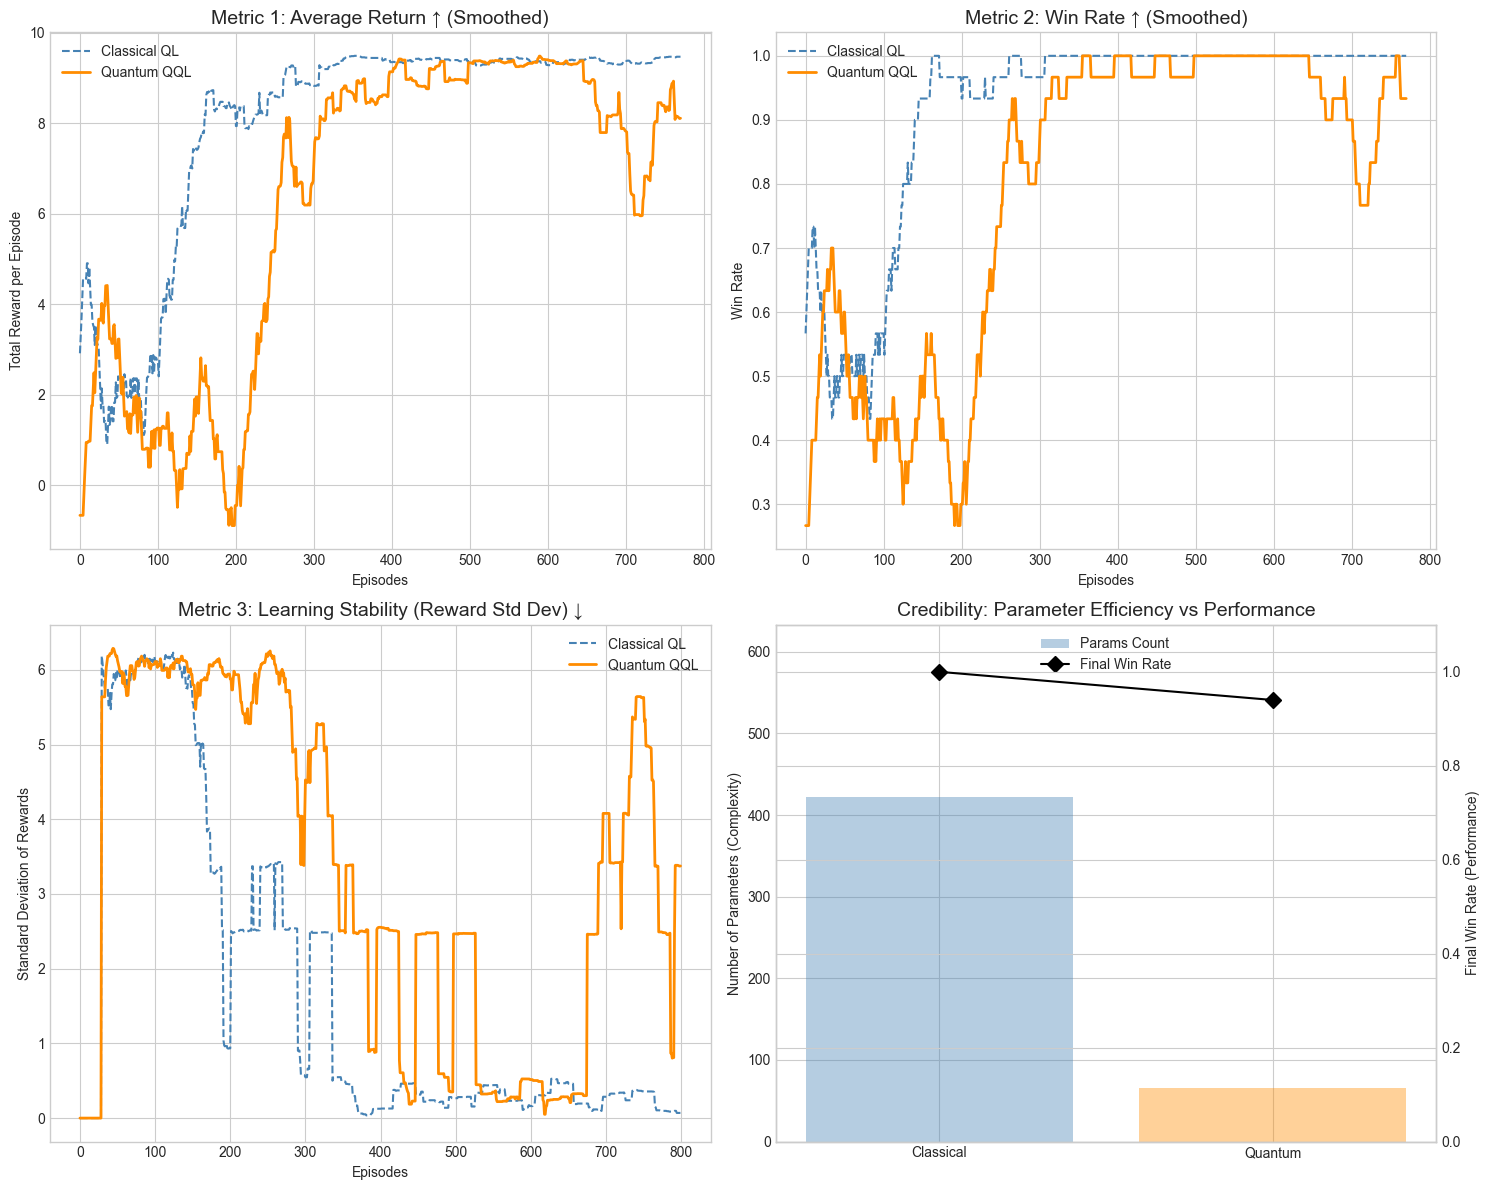

In [8]:

#  8. Visual comparative analysis

plt.style.use('seaborn-v0_8-whitegrid')

fig, axs = plt.subplots(2, 2, figsize=(15, 12))

def smooth(data, window=30):
    if len(data) < window: return data
    return np.convolve(data, np.ones(window)/window, mode='valid')

def rolling_std(data, window=30):
    return pd.Series(data).rolling(window=window).std().fillna(0).tolist()

# --- Sub-figure 1: Average return ---
axs[0,0].plot(smooth(c_history['rewards']), label='Classical QL', color='steelblue', linestyle='--')
axs[0,0].plot(smooth(q_history['rewards']), label='Quantum QQL', color='darkorange', linewidth=2)
axs[0,0].set_title("Metric 1: Average Return ↑ (Smoothed)", fontsize=14)
axs[0,0].set_ylabel("Total Reward per Episode")
axs[0,0].set_xlabel("Episodes")
axs[0,0].legend()

# --- Sub-chart 2: Win rate ---
axs[0,1].plot(smooth(c_history['success']), label='Classical QL', color='steelblue', linestyle='--')
axs[0,1].plot(smooth(q_history['success']), label='Quantum QQL', color='darkorange', linewidth=2)
axs[0,1].set_title("Metric 2: Win Rate ↑ (Smoothed)", fontsize=14)
axs[0,1].set_ylabel("Win Rate")
axs[0,1].set_xlabel("Episodes")
axs[0,1].legend()

# --- Subfigure 3: Stability of the learning curve ---
axs[1,0].plot(rolling_std(c_history['rewards']), label='Classical QL', color='steelblue', linestyle='--')
axs[1,0].plot(rolling_std(q_history['rewards']), label='Quantum QQL', color='darkorange', linewidth=2)
axs[1,0].set_title("Metric 3: Learning Stability (Reward Std Dev) ↓", fontsize=14)
axs[1,0].set_ylabel("Standard Deviation of Rewards")
axs[1,0].set_xlabel("Episodes")
axs[1,0].legend()

# --- Sub-figure 4: Comprehensive comparison of parameters and final win rate ---
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

q_net = QQLNet(n_layers=4)

c_params_count = c_history['param_count']
q_params_count = q_history['param_count']

labels = ['Classical', 'Quantum']
params = [c_params_count, q_params_count]
final_perf = [np.mean(c_history['success'][-50:]), np.mean(q_history['success'][-50:])]

axs[1,1].bar(labels, params, color=['steelblue', 'darkorange'], alpha=0.4, label='Params Count')
axs[1,1].set_ylabel("Number of Parameters (Complexity)")
axs[1,1].set_ylim(0, max(params) * 1.5)

ax2 = axs[1,1].twinx()
ax2.plot(labels, final_perf, color='black', marker='D', markersize=8, label='Final Win Rate')
ax2.set_ylabel("Final Win Rate (Performance)")
ax2.set_ylim(0, 1.1)

axs[1,1].set_title("Credibility: Parameter Efficiency vs Performance", fontsize=14)
lines, labels_l = axs[1,1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axs[1,1].legend(lines + lines2, labels_l + labels2, loc='upper center')

plt.tight_layout()
plt.show()